In [2]:
# ==========================================
# Titanic Survival Prediction
# Step 1: Import Libraries
# ==========================================

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Save Model
import joblib

In [3]:
# ==========================================
# Step 2: Load Dataset
# ==========================================

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Titanic-Dataset.csv")

# Display first 5 rows
df.head()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# ==========================================
# Step 3: Understand the Dataset
# ==========================================

# Shape of dataset
print("Shape of Dataset:")
print(df.shape)

print("\n")

# Column Names
print("Column Names:")
print(df.columns)

print("\n")

# Dataset Information
print("Dataset Information:")
df.info()

print("\n")

# Statistical Summary
print("Statistical Summary:")
df.describe()

print("\n")

# Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

Shape of Dataset:
(891, 12)


Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Statistical Summary:



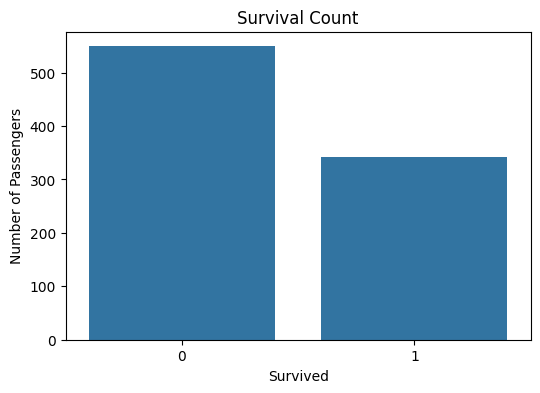

In [5]:
# ==========================================
# Survival Count
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x="Survived", data=df)

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

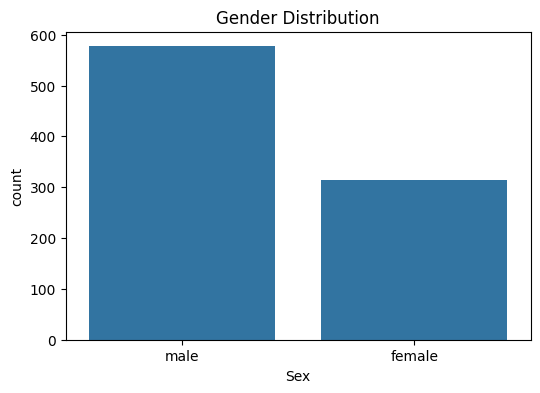

In [6]:
# ==========================================
# Gender Distribution
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")

plt.show()

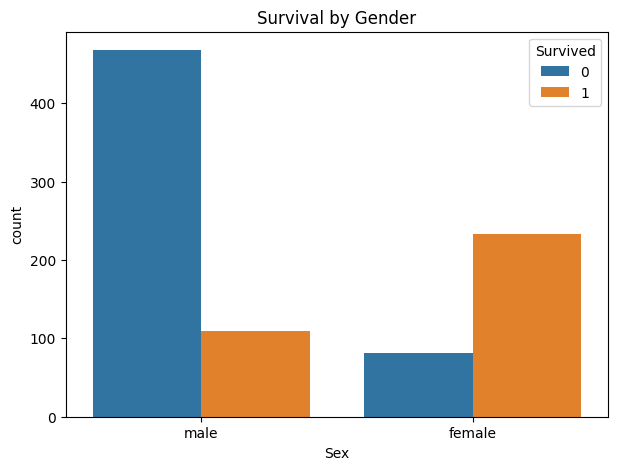

In [7]:
# ==========================================
# Survival by Gender
# ==========================================

plt.figure(figsize=(7,5))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")

plt.show()

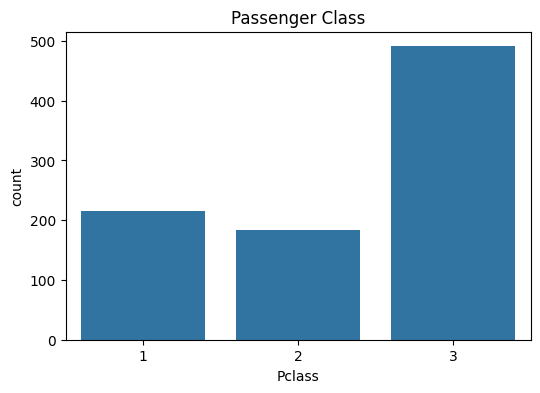

In [8]:
# ==========================================
# Passenger Class
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class")

plt.show()

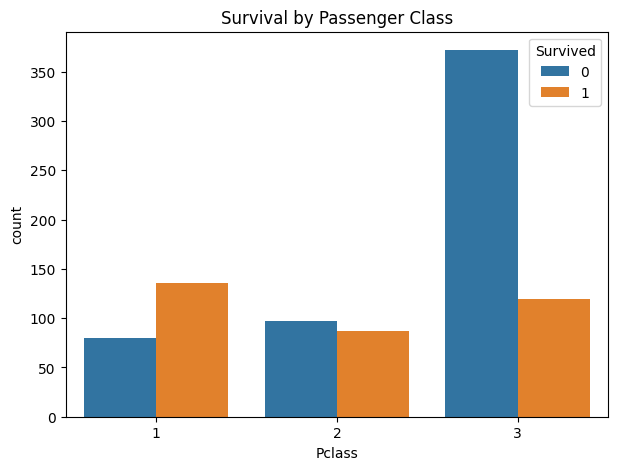

In [9]:
# ==========================================
# Survival by Passenger Class
# ==========================================

plt.figure(figsize=(7,5))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")

plt.show()

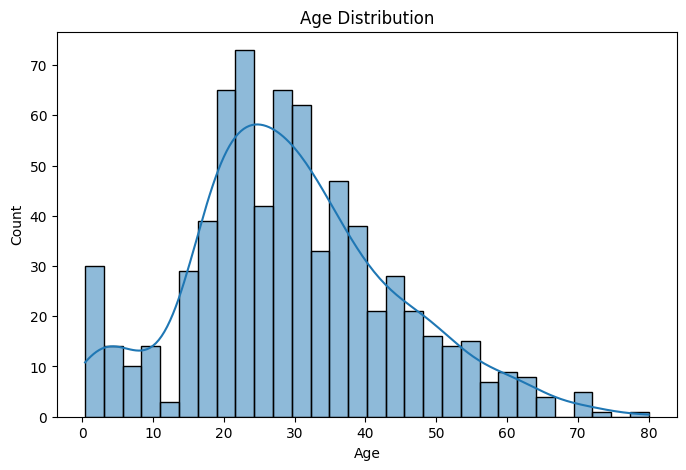

In [10]:
# ==========================================
# Age Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.show()

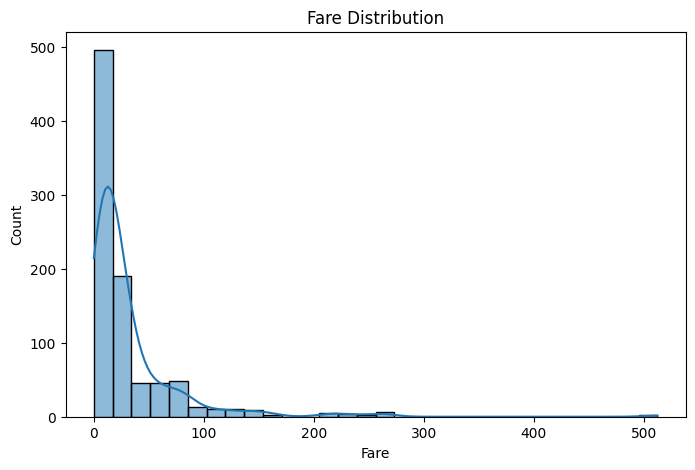

In [11]:
# ==========================================
# Fare Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Fare Distribution")

plt.show()

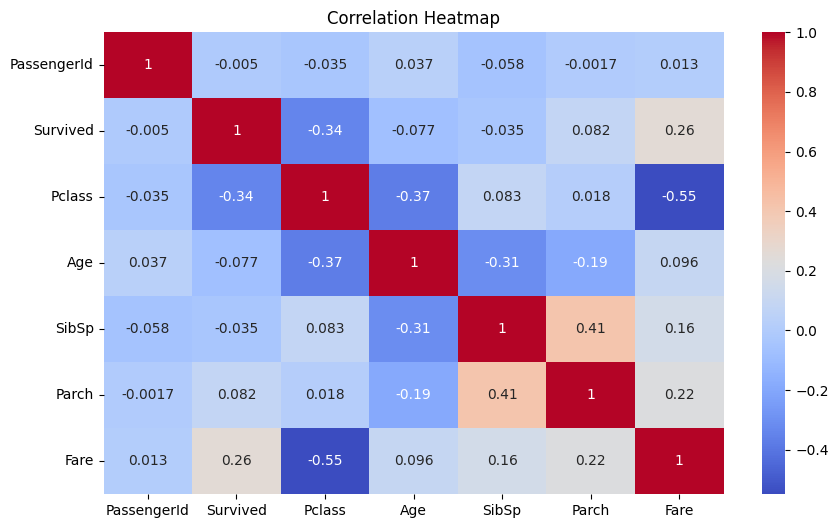

In [12]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [13]:
# ==========================================
# Check Missing Values
# ==========================================

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:

# ==========================================
# Fill Missing Age
# ==========================================

df["Age"] = df["Age"].fillna(df["Age"].median())


In [15]:
# ==========================================
# Fill Missing Embarked
# ==========================================

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [16]:
# ==========================================
# Remove Cabin Column
# ==========================================

df.drop("Cabin", axis=1, inplace=True)

In [17]:
# ==========================================
# Remove Unnecessary Columns
# ==========================================

df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [18]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [19]:
# ==========================================
# Encode Sex Column
# ==========================================

encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


In [20]:
# ==========================================
# Encode Embarked
# ==========================================

df["Embarked"] = encoder.fit_transform(df["Embarked"])

df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [21]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [22]:
# ==========================================
# Feature Selection
# ==========================================

# Independent Variables (Features)
X = df.drop("Survived", axis=1)

# Target Variable
y = df["Survived"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  22.0      1      0   7.2500         2
1       1    0  38.0      1      0  71.2833         0
2       3    0  26.0      0      0   7.9250         2
3       1    0  35.0      1      0  53.1000         2
4       3    1  35.0      0      0   8.0500         2

Target (y):
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [23]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (712, 7)
Testing Data Shape: (179, 7)


In [24]:
# ==========================================
# Train Random Forest Model
# ==========================================

model = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [25]:
# ==========================================
# Step 10: Make Predictions
# ==========================================

# Predict on test data
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[0 0 0 1 0 1 1 0 1 1]


In [26]:
# ==========================================
# Step 11: Accuracy
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8212290502793296


In [27]:
# ==========================================
# Step 12: Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[92 13]
 [19 55]]


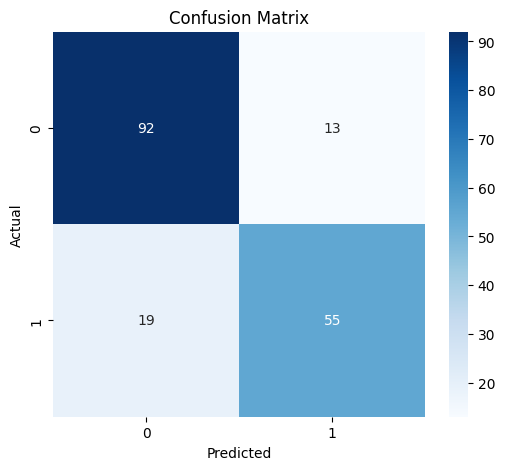

In [28]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [29]:
# ==========================================
# Step 13: Classification Report
# ==========================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [30]:
# ==========================================
# Step 14: Feature Importance
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

    Feature  Importance
1       Sex    0.271410
5      Fare    0.265010
2       Age    0.249995
0    Pclass    0.086957
3     SibSp    0.053685
4     Parch    0.039897
6  Embarked    0.033044


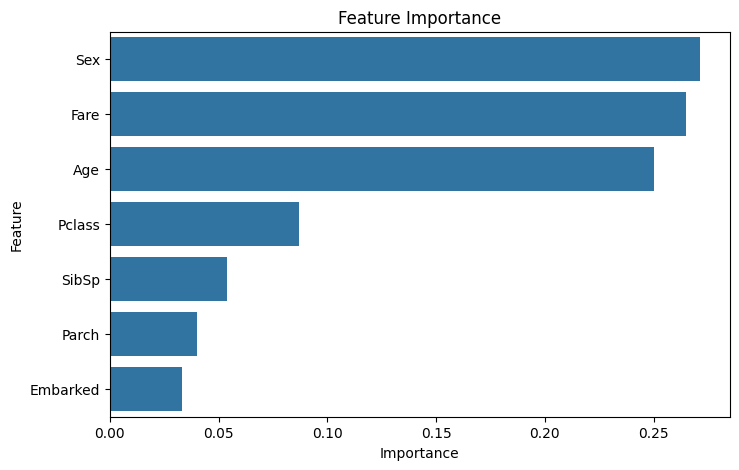

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()
